# Transferencia de calor transitoria: cocción de un bistec de carne
## Aproximación de un término (Heisler / one-term approximation)

**Curso:** Transferencia de Calor — Pregrado
**Tema:** Conducción transitoria, número de Biot, número de Fourier, gráficas/aproximación de Heisler

---

### Objetivos de aprendizaje

Al terminar este notebook el estudiante debe ser capaz de:

1. Reconocer cuándo un problema de conducción transitoria **no** puede resolverse con el modelo de capacitancia agrupada (sistema concentrado).
2. Plantear un bistec como una **pared plana infinita** con convección simétrica en ambas caras.
3. Calcular el número de Biot ($Bi$) y el número de Fourier ($Fo$).
4. Obtener los coeficientes $\lambda_1$ y $A_1$ resolviendo la ecuación trascendental de la aproximación de un término (en vez de leerlos de una tabla).
5. Calcular la temperatura en cualquier posición y tiempo, y el calor total transferido.
6. Reconocer el **rango de validez** de la aproximación de un término ($Fo>0.2$) y qué pasa fuera de ese rango.
7. Estimar el tiempo de cocción necesario para alcanzar un término de cocción deseado.

> Este notebook está pensado para **Google Colab**. Todas las celdas de código son autocontenidas: solo se necesitan librerías estándar de cómputo científico (`numpy`, `scipy`, `matplotlib`, `pandas`).


## 1. Fundamento teórico

### 1.1 ¿Por qué no usamos capacitancia agrupada?

El modelo de **sistema concentrado** (temperatura uniforme en todo el sólido) es válido solo si la resistencia interna a la conducción es mucho menor que la resistencia externa a la convección, es decir:

$$Bi = \frac{h L_c}{k} < 0.1$$

Cuando $Bi \geq 0.1$, el sólido desarrolla gradientes de temperatura internos apreciables y **debe resolverse la ecuación de conducción transitoria**. Como veremos, el bistec cae en este segundo caso.

### 1.2 Planteamiento: pared plana infinita

Un bistec es mucho más ancho y largo que grueso. Por eso se modela como una **pared plana de espesor $2L$**, con convección simétrica $h,\,T_\infty$ en ambas caras, inicialmente a temperatura uniforme $T_i$. La ecuación de conducción 1‑D transitoria, sin generación, es:

$$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}, \qquad \alpha = \frac{k}{\rho c_p}$$

con condiciones de frontera de simetría en el centro y convección en la superficie:

$$\left.\frac{\partial T}{\partial x}\right|_{x=0} = 0 \qquad\qquad -k\left.\frac{\partial T}{\partial x}\right|_{x=L} = h\big(T(L,t)-T_\infty\big)$$

y condición inicial $T(x,0) = T_i$.

### 1.3 Solución en serie y aproximación de un término

La solución exacta es una serie infinita de Fourier. Definiendo la temperatura adimensional

$$\theta^*(x,t) = \frac{T(x,t)-T_\infty}{T_i-T_\infty}$$

se obtiene

$$\theta^*(x,t) = \sum_{n=1}^{\infty} C_n \, e^{-\lambda_n^2 Fo} \cos\!\left(\lambda_n \frac{x}{L}\right), \qquad
C_n = \frac{4\sin\lambda_n}{2\lambda_n+\sin(2\lambda_n)}$$

donde los $\lambda_n$ son las raíces positivas de la **ecuación trascendental**

$$\lambda_n \tan\lambda_n = Bi$$

y el número de Fourier es $Fo = \alpha t / L^2$.

Para $Fo > 0.2$ el primer término de la serie domina el resto (el error de truncar es menor al 2 %), lo que da la llamada **aproximación de un término (one‑term approximation)** — la base de las cartas de Heisler:

$$\theta_0^{*} = \frac{T_0-T_\infty}{T_i-T_\infty} \approx A_1\, e^{-\lambda_1^2 Fo} \qquad \text{(temperatura en el centro, } x=0\text{)}$$

$$\frac{\theta^*(x)}{\theta_0^{*}} = \cos\!\left(\lambda_1\frac{x}{L}\right) \qquad \text{(perfil espacial, relativo al centro)}$$

$$\frac{Q}{Q_{max}} = 1-\frac{\sin\lambda_1}{\lambda_1}\,\theta_0^{*} \qquad \text{(energía transferida hasta el instante } t\text{)}$$

con $Q_{max} = \rho V c_p (T_i-T_\infty)$ el máximo calor que el sólido podría intercambiar (si alcanzara $T_\infty$ en todo su volumen).

**Idea clave del notebook:** en vez de leer $\lambda_1$ y $A_1$ de una tabla (como en un libro de texto), los vamos a calcular numéricamente resolviendo $\lambda_1\tan\lambda_1=Bi$ con `scipy.optimize.brentq`. Esto es exacto y funciona para cualquier valor de $Bi$, no solo los tabulados.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 2. Planteamiento del problema

**Escenario:** un bistec de res, recién sacado del refrigerador, se introduce en un horno de convección forzada (aire caliente circulando) para cocinarlo.

- El bistec se modela como una **pared plana** de espesor total $2L$, con convección idéntica $h,\,T_\infty$ en ambas caras (arriba y abajo).
- Como el bistec es mucho más ancho/largo que grueso, la conducción lateral (por los bordes) se desprecia — es la simplificación estándar en libros de transferencia de calor para láminas delgadas de alimento.
- Se asume que las propiedades termofísicas de la carne son constantes (no cambian con la temperatura ni por la desnaturalización de proteínas — una simplificación razonable para un primer curso).

El eje $x$ se mide desde el **centro** del bistec ($x=0$) hasta la **superficie** ($x=L$).


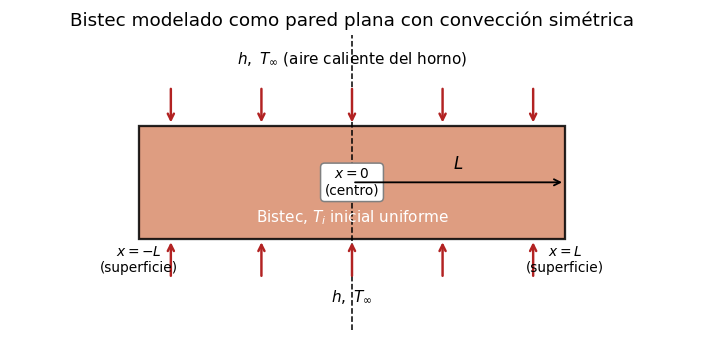

In [ ]:
# --- Esquema del problema -----------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 3.2))

L_plot = 1.0
rect = plt.Rectangle((-L_plot, 0), 2*L_plot, 1.0, facecolor="#d98c6b",
                      edgecolor="k", linewidth=1.5, alpha=0.85)
ax.add_patch(rect)

# flechas de conveccion arriba y abajo
for xi in np.linspace(-0.85, 0.85, 5):
    ax.annotate("", xy=(xi, 1.0), xytext=(xi, 1.35),
                arrowprops=dict(arrowstyle="->", color="firebrick", lw=1.6))
    ax.annotate("", xy=(xi, 0.0), xytext=(xi, -0.35),
                arrowprops=dict(arrowstyle="->", color="firebrick", lw=1.6))

ax.text(0, 1.55, r"$h,\ T_\infty$ (aire caliente del horno)", ha="center", fontsize=10)
ax.text(0, -0.55, r"$h,\ T_\infty$", ha="center", fontsize=10)

ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.text(0, 0.5, r"$x=0$" "\n(centro)", ha="center", va="center", fontsize=9,
        bbox=dict(boxstyle="round", fc="white", ec="gray"))
ax.annotate("", xy=(L_plot, 0.5), xytext=(0, 0.5),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2))
ax.text(L_plot*0.5, 0.62, "$L$", ha="center", fontsize=11)
ax.text(-L_plot, -0.05, "$x=-L$\n(superficie)", ha="center", va="top", fontsize=9)
ax.text(L_plot, -0.05, "$x=L$\n(superficie)", ha="center", va="top", fontsize=9)
ax.text(0, 0.15, r"Bistec, $T_i$ inicial uniforme", ha="center", fontsize=10, color="white")

ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-0.8, 1.8)
ax.axis("off")
ax.set_title("Bistec modelado como pared plana con convección simétrica")
plt.tight_layout()
plt.show()


## 3. Propiedades termofísicas y condiciones del problema

Los valores típicos de propiedades térmicas de carne de res cruda (composición ≈ 75 % agua) usados en ingeniería de alimentos son del siguiente orden (pueden variar ±15-20 % según el corte, el contenido de grasa y la temperatura):

| Propiedad | Símbolo | Valor típico |
|---|---|---|
| Conductividad térmica | $k$ | 0.45 – 0.50 W/m·K |
| Densidad | $\rho$ | 1000 – 1070 kg/m³ |
| Calor específico | $c_p$ | 3400 – 3600 J/kg·K |

**Nota didáctica:** estos valores se pueden y deben cambiar para explorar sensibilidad (ver sección de ejercicios al final).


In [ ]:
# --- Propiedades termofisicas de la carne (valores tipicos, res cruda) ---
k   = 0.48     # W/m-K      conductividad termica
rho = 1050.0   # kg/m3      densidad
cp  = 3540.0   # J/kg-K     calor especifico
alpha = k / (rho * cp)   # m2/s   difusividad termica

# --- Geometria: bistec como pared plana --------------------------------
espesor_total = 0.03      # m  (3 cm de espesor)
L = espesor_total / 2     # m  semiespesor (longitud caracteristica)
ancho  = 0.15              # m
largo  = 0.10               # m

# --- Condiciones de proceso ---------------------------------------------
Ti   = 4.0     # C   temperatura inicial (refrigerador)
Tinf = 200.0   # C   temperatura del aire del horno
h    = 60.0    # W/m2-K   coeficiente de conveccion (horno con conveccion forzada)

props = pd.DataFrame({
    "Símbolo": ["k", "ρ", "cp", "α", "L (semiespesor)", "Ti", "T∞", "h"],
    "Valor": [k, rho, cp, alpha, L, Ti, Tinf, h],
    "Unidad": ["W/m·K", "kg/m³", "J/kg·K", "m²/s", "m", "°C", "°C", "W/m²·K"],
    "Descripción": ["Conductividad térmica", "Densidad", "Calor específico",
                     "Difusividad térmica (=k/ρcp)", "Semiespesor del bistec",
                     "Temperatura inicial (refrigerador)",
                     "Temperatura del aire del horno",
                     "Coeficiente de convección"]
})
props


,Símbolo,Valor,Unidad,Descripción
0,k,4.800000e-01,W/m·K,Conductividad térmica
1,ρ,1.050000e+03,kg/m³,Densidad
2,cp,3.540000e+03,J/kg·K,Calor específico
3,α,1.291364e-07,m²/s,Difusividad térmica (=k/ρcp)
4,L (semiespesor),1.500000e-02,m,Semiespesor del bistec
5,Ti,4.000000e+00,°C,Temperatura inicial (refrigerador)
6,T∞,2.000000e+02,°C,Temperatura del aire del horno
7,h,6.000000e+01,W/m²·K,Coeficiente de convección


## 4. Número de Biot y validez del modelo de capacitancia agrupada


In [ ]:
Bi = h * L / k
print(f"Numero de Biot, Bi = h*L/k = {Bi:.4f}")

if Bi < 0.1:
    print("Bi < 0.1  ->  el modelo de capacitancia agrupada SI seria valido.")
else:
    print("Bi >= 0.1 -> el gradiente de temperatura interno NO es despreciable.")
    print("             Se necesita la solucion de conduccion transitoria (Heisler).")


Numero de Biot, Bi = h*L/k = 1.8750
Bi >= 0.1 -> el gradiente de temperatura interno NO es despreciable.
             Se necesita la solucion de conduccion transitoria (Heisler).


## 5. Cálculo de $\lambda_1$ y $A_1$ (aproximación de un término)

En vez de interpolar en una tabla de un libro, resolvemos numéricamente la ecuación trascendental

$$\lambda_1 \tan\lambda_1 = Bi$$

La primera raíz positiva se encuentra en el intervalo $(0,\ \pi/2)$ (ahí es donde $\tan\lambda$ pasa de 0 a $+\infty$, garantizando una única raíz en ese intervalo para cualquier $Bi>0$).


In [ ]:
def ecuacion_caracteristica(lam, Bi):
    '''lambda*tan(lambda) - Bi = 0 : raices dan los lambda_n de la pared plana.'''
    return lam * np.tan(lam) - Bi

# primera raiz: esta en (0, pi/2), evitando la asintota de tan en pi/2
lam1 = brentq(ecuacion_caracteristica, 1e-6, np.pi/2 - 1e-6, args=(Bi,))

# coeficiente A1 (=C1) de la aproximacion de un termino
A1 = 4 * np.sin(lam1) / (2*lam1 + np.sin(2*lam1))

print(f"lambda_1 = {lam1:.5f} rad")
print(f"A_1      = {A1:.5f}")


lambda_1 = 1.05733 rad
A_1      = 1.17298


## 6. Funciones de temperatura y número de Fourier

Definimos funciones reutilizables para el número de Fourier, la temperatura adimensional en el centro y el perfil espacial.


In [ ]:
def fourier(t):
    '''Numero de Fourier Fo = alpha*t/L^2  (t en segundos).'''
    return alpha * t / L**2

def theta0_star(Fo):
    '''Temperatura adimensional en el centro (x=0), aproximacion de un termino.'''
    return A1 * np.exp(-lam1**2 * Fo)

def perfil_relativo(x):
    '''theta*(x) / theta0*  , con x medido desde el centro (m).'''
    return np.cos(lam1 * x / L)

def temperatura(x, t):
    '''Temperatura T(x,t) en grados C. x en m (0=centro, +-L=superficie), t en s.'''
    Fo = fourier(t)
    th0 = theta0_star(Fo)
    th = th0 * perfil_relativo(x)
    return Tinf + th * (Ti - Tinf)


## 7. Temperatura en el centro, punto medio y superficie a distintos tiempos

Calculamos la temperatura en tres posiciones representativas ($x=0$ centro, $x=L/2$, $x=L$ superficie) para una serie de tiempos de cocción, y marcamos si en ese instante se cumple el criterio de validez $Fo>0.2$.


In [ ]:
tiempos_min = np.array([1, 2, 4, 6, 8, 10, 12, 15, 20, 25])
tiempos_s = tiempos_min * 60

Fo_vals   = fourier(tiempos_s)
T_centro  = temperatura(0.0,   tiempos_s)
T_medio   = temperatura(L/2,   tiempos_s)
T_super   = temperatura(L,     tiempos_s)
valido    = Fo_vals > 0.2

tabla = pd.DataFrame({
    "t (min)": tiempos_min,
    "Fo": Fo_vals.round(3),
    "Fo>0.2 (valido)": valido,
    "T centro (C)": T_centro.round(1),
    "T medio, x=L/2 (C)": T_medio.round(1),
    "T superficie (C)": T_super.round(1),
})
tabla


,t (min),Fo,Fo>0.2 (valido),T centro (C),"T medio, x=L/2 (C)",T superficie (C)
0,1,0.034,False,-21.2,9.0,91.3
1,2,0.069,False,-12.9,16.2,95.4
2,4,0.138,False,2.9,29.8,103.2
3,6,0.207,True,17.5,42.4,110.4
4,8,0.275,True,31.0,54.1,117.0
5,10,0.344,True,43.6,64.9,123.2
6,12,0.413,True,55.2,74.9,128.9
7,15,0.517,True,71.0,88.6,136.6
8,20,0.689,True,93.5,108.1,147.7
9,25,0.861,True,112.2,124.2,156.9


**Observación importante:** para los primeros minutos ($Fo<0.2$, filas marcadas como `False`) la aproximación de un término puede dar resultados **poco realistas** (e.g. temperaturas del centro por debajo de la temperatura inicial). Esto **no es un error de cálculo**: es la consecuencia directa de truncar la serie infinita a un solo término antes de que ese término domine. En la Sección 11 comparamos con la serie completa para confirmarlo.


## 8. Evolución temporal de la temperatura


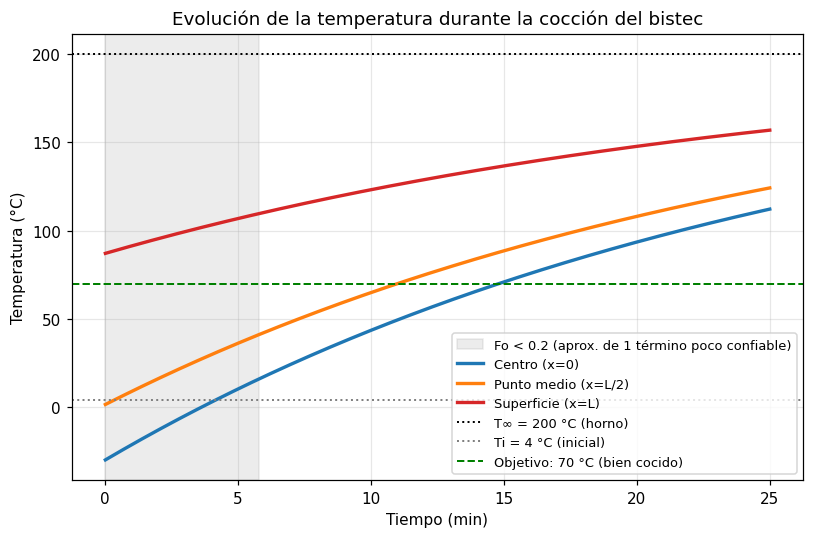

In [ ]:
t_cont_s = np.linspace(1, 25*60, 400)
Fo_cont  = fourier(t_cont_s)

T_centro_c = temperatura(0.0, t_cont_s)
T_medio_c  = temperatura(L/2, t_cont_s)
T_super_c  = temperatura(L,   t_cont_s)

fig, ax = plt.subplots(figsize=(7.5, 5))

# sombrear la zona no valida (Fo < 0.2)
t_no_valido = t_cont_s[Fo_cont <= 0.2]
if len(t_no_valido) > 0:
    ax.axvspan(0, t_no_valido.max()/60, color="grey", alpha=0.15,
               label="Fo < 0.2 (aprox. de 1 término poco confiable)")

ax.plot(t_cont_s/60, T_centro_c, label="Centro (x=0)", lw=2.2, color="#1f77b4")
ax.plot(t_cont_s/60, T_medio_c,  label="Punto medio (x=L/2)", lw=2.2, color="#ff7f0e")
ax.plot(t_cont_s/60, T_super_c,  label="Superficie (x=L)", lw=2.2, color="#d62728")

ax.axhline(Tinf, color="k", linestyle=":", lw=1.3, label=f"T∞ = {Tinf:.0f} °C (horno)")
ax.axhline(Ti,   color="grey", linestyle=":", lw=1.3, label=f"Ti = {Ti:.0f} °C (inicial)")
ax.axhline(70, color="green", linestyle="--", lw=1.3, label="Objetivo: 70 °C (bien cocido)")

ax.set_xlabel("Tiempo (min)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Evolución de la temperatura durante la cocción del bistec")
ax.legend(loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.show()


## 9. Perfiles espaciales de temperatura

Ahora fijamos el tiempo y recorremos el espesor del bistec, de superficie a superficie ($-L \le x \le L$), para varios instantes.


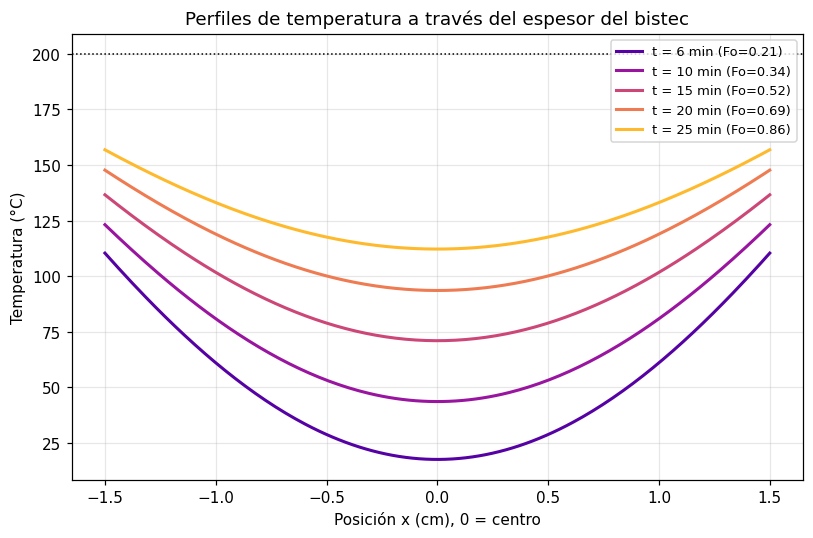

In [ ]:
x_vals = np.linspace(-L, L, 200)
tiempos_perfil_min = [6, 10, 15, 20, 25]

fig, ax = plt.subplots(figsize=(7.5, 5))
cmap = plt.cm.plasma(np.linspace(0.15, 0.85, len(tiempos_perfil_min)))

for tmin, color in zip(tiempos_perfil_min, cmap):
    t_s = tmin * 60
    T_perfil = temperatura(x_vals, t_s)
    ax.plot(x_vals*100, T_perfil, color=color, lw=2, label=f"t = {tmin} min (Fo={fourier(t_s):.2f})")

ax.axhline(Tinf, color="k", linestyle=":", lw=1)
ax.set_xlabel("Posición x (cm), 0 = centro")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Perfiles de temperatura a través del espesor del bistec")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()


## 10. Tiempo necesario para un término de cocción deseado

Invertimos la ecuación de $\theta_0^{*}$ para despejar el número de Fourier (y luego el tiempo) requerido para que el **centro** del bistec alcance una temperatura objetivo $T_{obj}$:

$$Fo = -\frac{1}{\lambda_1^2}\ln\!\left(\frac{\theta_{0,obj}^{*}}{A_1}\right), \qquad
\theta_{0,obj}^{*} = \frac{T_{obj}-T_\infty}{T_i-T_\infty}$$

$$t = \frac{Fo\,L^2}{\alpha}$$

Esto solo tiene sentido si el resultado cae en la zona válida ($Fo>0.2$); de lo contrario el resultado no es confiable con este método.


In [ ]:
def tiempo_para_temperatura_centro(T_obj):
    '''Tiempo (s) para que el CENTRO del bistec alcance T_obj (C).'''
    th0_obj = (T_obj - Tinf) / (Ti - Tinf)
    Fo_obj = -np.log(th0_obj / A1) / lam1**2
    t_obj = Fo_obj * L**2 / alpha
    return t_obj, Fo_obj

terminos_coccion = {
    "Término medio (~63 °C)": 63.0,
    "Término tres cuartos (~68 °C)": 68.0,
    "Bien cocido (~70-71 °C)": 70.0,
}

filas = []
for nombre, T_obj in terminos_coccion.items():
    t_obj, Fo_obj = tiempo_para_temperatura_centro(T_obj)
    filas.append({
        "Término": nombre,
        "T objetivo centro (C)": T_obj,
        "Fo requerido": round(Fo_obj, 3),
        "t requerido (min)": round(t_obj/60, 1),
        "Fo>0.2 (valido)": Fo_obj > 0.2,
    })

tabla_coccion = pd.DataFrame(filas)
tabla_coccion


,Término,T objetivo centro (C),Fo requerido,t requerido (min),Fo>0.2 (valido)
0,Término medio (~63 °C),63.0,0.463,13.4,True
1,Término tres cuartos (~68 °C),68.0,0.496,14.4,True
2,Bien cocido (~70-71 °C),70.0,0.510,14.8,True


## 11. Calor total transferido al bistec

La fracción de energía intercambiada respecto al máximo posible ($Q_{max}$, si todo el bistec llegara a $T_\infty$) se calcula, en la aproximación de un término, como:

$$\frac{Q}{Q_{max}} = 1-\frac{\sin\lambda_1}{\lambda_1}\,\theta_0^{*}, \qquad
Q_{max} = \rho\,V\,c_p\,(T_i-T_\infty)$$


Volumen del bistec        : 450.0 cm3
Masa del bistec            : 472 g
Qmax                       : -327.8 kJ  (energia maxima intercambiable)


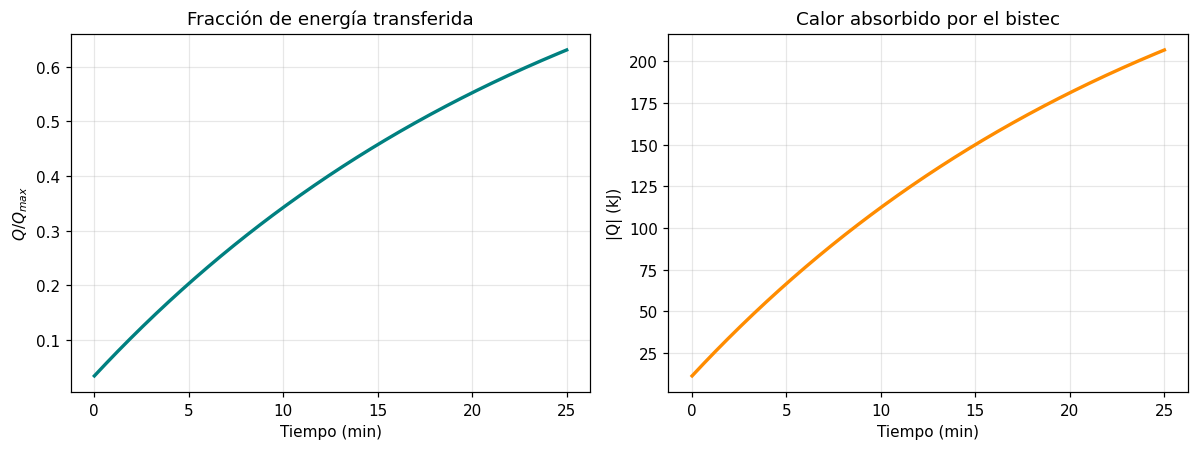

In [ ]:
V = ancho * largo * espesor_total   # m3, volumen del bistec
masa = rho * V

Qmax = masa * cp * (Ti - Tinf)   # J (negativo: el bistec GANA calor, Tinf > Ti)

def fraccion_energia(Fo):
    th0 = theta0_star(Fo)
    return 1 - (np.sin(lam1)/lam1) * th0

QoQmax_cont = fraccion_energia(Fo_cont)
Q_cont_kJ = QoQmax_cont * Qmax / 1000.0   # kJ

print(f"Volumen del bistec        : {V*1e6:.1f} cm3")
print(f"Masa del bistec            : {masa*1000:.0f} g")
print(f"Qmax                       : {Qmax/1000:.1f} kJ  (energia maxima intercambiable)")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))

axs[0].plot(t_cont_s/60, QoQmax_cont, color="teal", lw=2.2)
axs[0].set_xlabel("Tiempo (min)")
axs[0].set_ylabel(r"$Q/Q_{max}$")
axs[0].set_title("Fracción de energía transferida")

axs[1].plot(t_cont_s/60, np.abs(Q_cont_kJ), color="darkorange", lw=2.2)
axs[1].set_xlabel("Tiempo (min)")
axs[1].set_ylabel("|Q| (kJ)")
axs[1].set_title("Calor absorbido por el bistec")

plt.tight_layout()
plt.show()


## 12. ¿Qué tan mal se equivoca el modelo de capacitancia agrupada?

Ya vimos que $Bi>0.1$, así que el modelo de capacitancia agrupada **no debería usarse**. Aun así, es instructivo calcularlo y compararlo con la solución correcta (centro, Heisler) para **ver la magnitud del error** que se cometería si, por error, se aplicara de todas formas.

El modelo de capacitancia agrupada asume temperatura uniforme $T(t)$ en todo el sólido:

$$\frac{T(t)-T_\infty}{T_i-T_\infty} = \exp\!\left(-\frac{h A_s}{\rho V c_p}\,t\right)$$


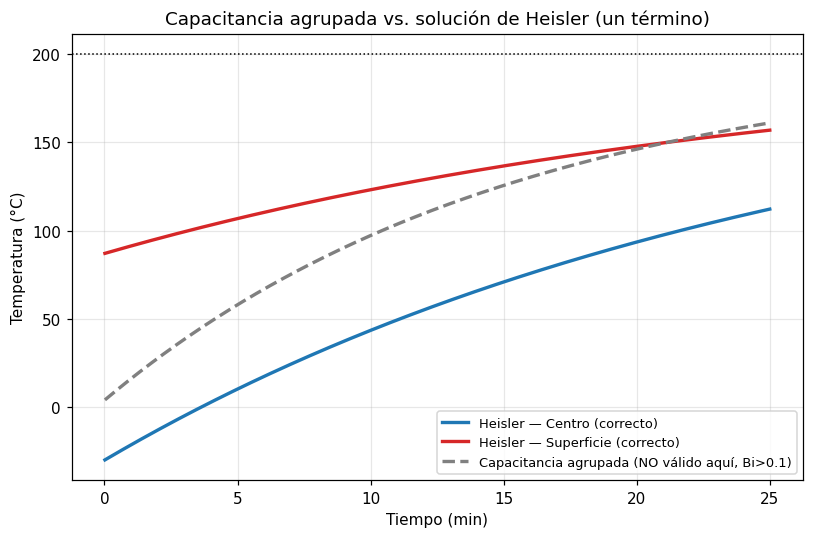

Bi = 1.87  (>> 0.1)  ->  el modelo agrupado subestima fuertemente
el tiempo real de calentamiento del centro del bistec.


In [ ]:
A_s = 2 * ancho * largo   # area de las dos caras que convectan (m2)
tau_lumped = (rho * V * cp) / (h * A_s)

T_lumped = Tinf + (Ti - Tinf) * np.exp(-t_cont_s / tau_lumped)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(t_cont_s/60, T_centro_c, color="#1f77b4", lw=2.2, label="Heisler — Centro (correcto)")
ax.plot(t_cont_s/60, T_super_c,  color="#d62728", lw=2.2, label="Heisler — Superficie (correcto)")
ax.plot(t_cont_s/60, T_lumped,   color="grey", lw=2.2, ls="--",
        label="Capacitancia agrupada (NO válido aquí, Bi>0.1)")
ax.axhline(Tinf, color="k", linestyle=":", lw=1)
ax.set_xlabel("Tiempo (min)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Capacitancia agrupada vs. solución de Heisler (un término)")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

print(f"Bi = {Bi:.2f}  (>> 0.1)  ->  el modelo agrupado subestima fuertemente")
print("el tiempo real de calentamiento del centro del bistec.")


## 13. Verificación: serie completa vs. aproximación de un término

Para confirmar por qué se exige $Fo>0.2$, calculamos las primeras $N$ raíces $\lambda_n$ de $\lambda_n\tan\lambda_n=Bi$ (una en cada intervalo $((n-1)\pi,\ (n-1)\pi+\pi/2)$) y sumamos varios términos de la serie completa:

$$\theta_0^{*}(Fo) = \sum_{n=1}^{N} C_n\, e^{-\lambda_n^2 Fo}$$

Comparamos esta serie "casi exacta" con la aproximación de un término, especialmente en los primeros minutos.


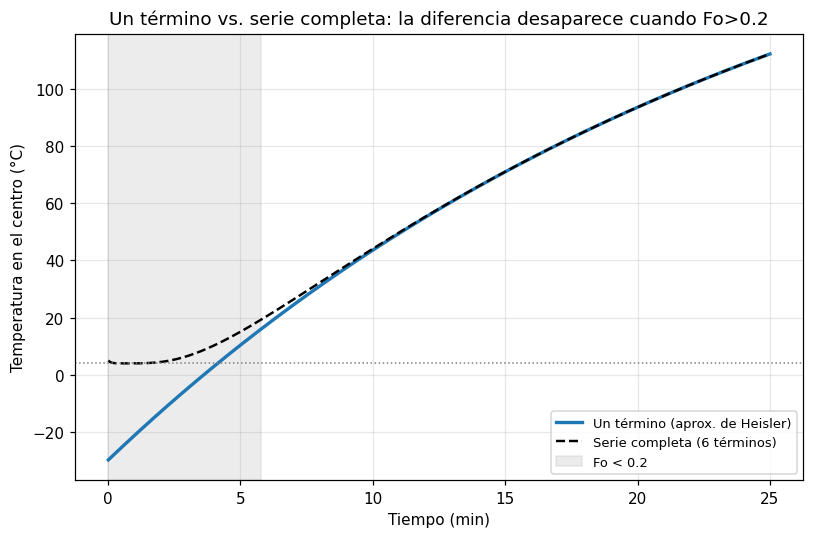

Diferencia (serie completa - un termino) en el centro, por tiempo:
  t= 1 min  Fo=0.034  1-termino= -21.22 C   serie=   4.01 C   diff=-25.23 C
  t= 2 min  Fo=0.069  1-termino= -12.87 C   serie=   4.49 C   diff=-17.36 C
  t= 4 min  Fo=0.138  1-termino=   2.91 C   serie=  10.23 C   diff= -7.32 C
  t= 6 min  Fo=0.207  1-termino=  17.51 C   serie=  20.50 C   diff= -2.99 C
  t=10 min  Fo=0.344  1-termino=  43.56 C   serie=  44.05 C   diff= -0.49 C


In [ ]:
N_terminos = 6
lambdas = []
for n in range(1, N_terminos + 1):
    lo = (n - 1) * np.pi + 1e-6
    hi = (n - 1) * np.pi + np.pi/2 - 1e-6
    lam_n = brentq(ecuacion_caracteristica, lo, hi, args=(Bi,))
    lambdas.append(lam_n)
lambdas = np.array(lambdas)
Cs = 4 * np.sin(lambdas) / (2*lambdas + np.sin(2*lambdas))

def theta0_serie_completa(Fo):
    Fo = np.atleast_1d(Fo).astype(float)
    theta = np.zeros_like(Fo)
    for lam_n, C_n in zip(lambdas, Cs):
        theta += C_n * np.exp(-lam_n**2 * Fo)
    return theta

Fo_check = fourier(t_cont_s)
T_centro_serie = Tinf + theta0_serie_completa(Fo_check) * (Ti - Tinf)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(t_cont_s/60, T_centro_c,     color="#1f77b4", lw=2.2, label="Un término (aprox. de Heisler)")
ax.plot(t_cont_s/60, T_centro_serie, color="black", lw=1.6, ls="--", label=f"Serie completa ({N_terminos} términos)")
if len(t_no_valido) > 0:
    ax.axvspan(0, t_no_valido.max()/60, color="grey", alpha=0.15, label="Fo < 0.2")
ax.axhline(Ti, color="grey", linestyle=":", lw=1)
ax.set_xlabel("Tiempo (min)")
ax.set_ylabel("Temperatura en el centro (°C)")
ax.set_title("Un término vs. serie completa: la diferencia desaparece cuando Fo>0.2")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

print("Diferencia (serie completa - un termino) en el centro, por tiempo:")
for tmin in [1, 2, 4, 6, 10]:
    t_s = tmin*60
    Fo_ = fourier(t_s)
    T1 = temperatura(0.0, t_s)
    Tn = Tinf + theta0_serie_completa(Fo_)[0]*(Ti-Tinf)
    print(f"  t={tmin:2d} min  Fo={Fo_:.3f}  1-termino={T1:7.2f} C   serie={Tn:7.2f} C   diff={T1-Tn:6.2f} C")


Como se observa, para $Fo<0.2$ el error del método de un término puede ser de **varias decenas de grados**, mientras que para $Fo>0.2$ la diferencia es de menos de 1 °C. Esto confirma numéricamente el criterio de validez que normalmente se da como una regla fija en los libros de texto.


## 14. (Avanzado, opcional) Bistec como paralelepípedo finito — solución producto

La pared plana infinita ignora la conducción por los bordes del bistec. Una forma más realista, sin resolver un problema 2D/3D desde cero, es usar la **solución producto de Heisler**: para un paralelepípedo (una "barra corta" en las 3 direcciones), la temperatura adimensional en el centro es el **producto** de tres soluciones de pared plana infinita, una por cada dirección (espesor, ancho y largo), cada una con su propio $Bi$ y $L$:

$$\theta_0^{*}\big|_{paralelepipedo} = \theta_0^{*}\big|_{espesor}\cdot\theta_0^{*}\big|_{ancho}\cdot\theta_0^{*}\big|_{largo}$$

Esto es exactamente la técnica que usan las cartas de Heisler para geometrías combinadas. Aquí la calculamos numéricamente reutilizando la función `theta0_star` con distintos $Bi$ y $L$ por dirección.


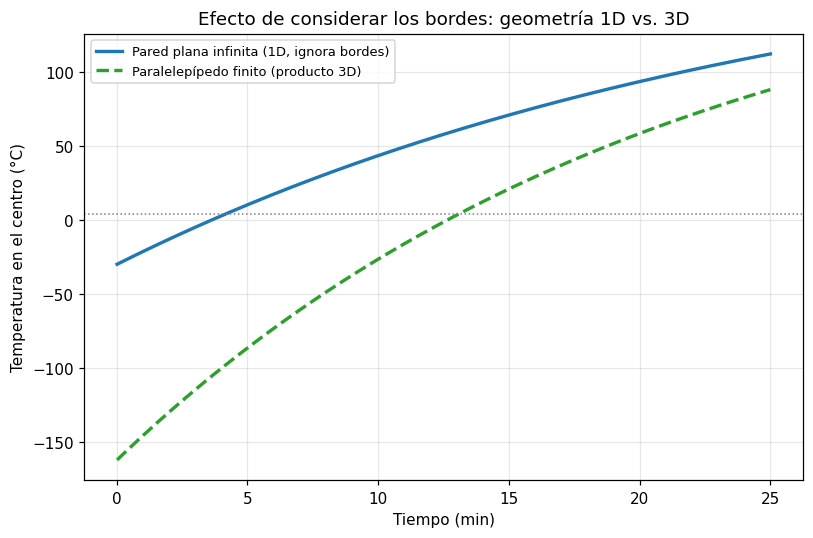

Como el bistec es mucho mas ancho/largo que grueso, ambas curvas
son muy parecidas: el modelo 1D es una buena aproximacion.
La diferencia crece si el bistec fuera mas 'cuadrado' (ancho y largo pequenos).


In [ ]:
def theta0_pared(L_dir, t):
    '''theta0* de una pared plana infinita de semiespesor L_dir, evaluada en t (s).'''
    Bi_dir = h * L_dir / k
    lam1_dir = brentq(ecuacion_caracteristica, 1e-6, np.pi/2 - 1e-6, args=(Bi_dir,))
    A1_dir = 4*np.sin(lam1_dir) / (2*lam1_dir + np.sin(2*lam1_dir))
    Fo_dir = alpha * t / L_dir**2
    return A1_dir * np.exp(-lam1_dir**2 * Fo_dir)

L_espesor = L
L_ancho   = ancho/2
L_largo   = largo/2

theta0_3D = (theta0_pared(L_espesor, t_cont_s)
             * theta0_pared(L_ancho, t_cont_s)
             * theta0_pared(L_largo, t_cont_s))

T_centro_3D = Tinf + theta0_3D * (Ti - Tinf)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(t_cont_s/60, T_centro_c,  color="#1f77b4", lw=2.2, label="Pared plana infinita (1D, ignora bordes)")
ax.plot(t_cont_s/60, T_centro_3D, color="#2ca02c", lw=2.2, ls="--", label="Paralelepípedo finito (producto 3D)")
ax.axhline(Ti, color="grey", linestyle=":", lw=1)
ax.set_xlabel("Tiempo (min)")
ax.set_ylabel("Temperatura en el centro (°C)")
ax.set_title("Efecto de considerar los bordes: geometría 1D vs. 3D")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

print("Como el bistec es mucho mas ancho/largo que grueso, ambas curvas")
print("son muy parecidas: el modelo 1D es una buena aproximacion.")
print("La diferencia crece si el bistec fuera mas 'cuadrado' (ancho y largo pequenos).")


## 15. Resumen

- El bistec ($Bi \approx 1.9$) **no** cumple el criterio de capacitancia agrupada ($Bi<0.1$): hay gradientes internos de temperatura importantes.
- Se modeló como una pared plana infinita, resolviendo $\lambda_1\tan\lambda_1=Bi$ numéricamente para obtener $\lambda_1$ y $A_1$ exactos (sin necesidad de tablas).
- La aproximación de un término es **confiable solo cuando $Fo>0.2$**; para tiempos muy cortos hay que usar la serie completa (o aceptar que el resultado no es físicamente correcto).
- Con las propiedades y condiciones usadas, el centro del bistec alcanza ~70 °C ("bien cocido") en aproximadamente **15 minutos**, mientras la superficie ya está muy por encima de esa temperatura — de ahí que la superficie se dore/cueza mucho antes que el centro.
- El modelo 1D (pared plana) es una excelente aproximación para un bistec, porque el espesor es mucho menor que el ancho y el largo; la extensión 3D (solución producto) lo confirma.

## 16. Ejercicios propuestos para los estudiantes

1. **Sensibilidad al espesor:** repita el cálculo para un bistec de 1.5 cm y de 5 cm de espesor. ¿Cómo cambia el tiempo para alcanzar 70 °C en el centro? ¿La relación es lineal con $L$?
2. **Efecto del coeficiente de convección:** compare $h=20$ W/m²K (horno convencional, convección natural) contra $h=100$ W/m²K (horno con ventilador potente / sartén). ¿Qué tanto se reduce el tiempo de cocción?
3. **Verifique el criterio de Biot:** encuentre el valor de $h$ (o de $L$) para el cual $Bi=0.1$ exactamente, y comente qué tan "delgado" tendría que ser el bistec para que la capacitancia agrupada fuera válida.
4. **Términos de cocción:** grafique el tiempo requerido para alcanzar la temperatura del centro correspondiente a término "azul/rojo inglés" (~ 49-52 °C), medio (~ 63 °C) y bien cocido (~ 71 °C), todos en una misma figura, en función del espesor del bistec.
5. **Congelado vs. refrigerado:** repita el análisis con $T_i = -18$ °C (bistec congelado). ¿Sigue siendo válida la aproximación de un término en los mismos tiempos? (Pista: revise si cambian las propiedades térmicas al congelarse — investigue valores típicos de $k$, $\rho$, $c_p$ para carne congelada.)
6. **Energía y costo:** con el valor de $Q$ calculado, y sabiendo la eficiencia y potencia del horno, estime cuánta energía eléctrica (kWh) se necesita para cocinar el bistec, y compare con el consumo típico de un horno doméstico.
